 Successfully imported project modules.
 Running on: cpu
Loading metadata from: C:\Datasets\OCTDL_Cleaned\OCTDL_clean_metadata.csv
   Classes (Disease): {'AMD': 0, 'DME': 1, 'ERM': 2, 'NO': 3, 'RAO': 4, 'RVO': 5, 'VID': 6}
   Classes (Condition): {'DRIL': 0, 'ERM': 1, 'ME': 2, 'MH': 3, 'MNV': 4, 'MNV_suspected': 5, 'NO': 6, 'drusen': 7}
Split Complete:
   Train: 1410 images (574 patients)
   Val:   209 images (82 patients)
   Test:  445 images (165 patients)
 Init model structure using: C:\Users\daria\PycharmProjects\Licenta_Final\saved_models\best_classifier.pth
Loading backbone architecture from Torch Hub...


Using cache found in C:\Users\daria/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\daria/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\daria/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\daria/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading custom weights from: C:\Users\daria\PycharmProjects\Licenta_Final\saved_models\best_classifier.pth
Backbone weights loaded successfully (Missing keys for head layers: 0)
Backbone is frozen. Only classification heads will be trained.
 Model weights loaded successfully.
 Extracting features for t-SNE...


100%|██████████| 14/14 [05:43<00:00, 24.52s/it]


Computing t-SNE projection...


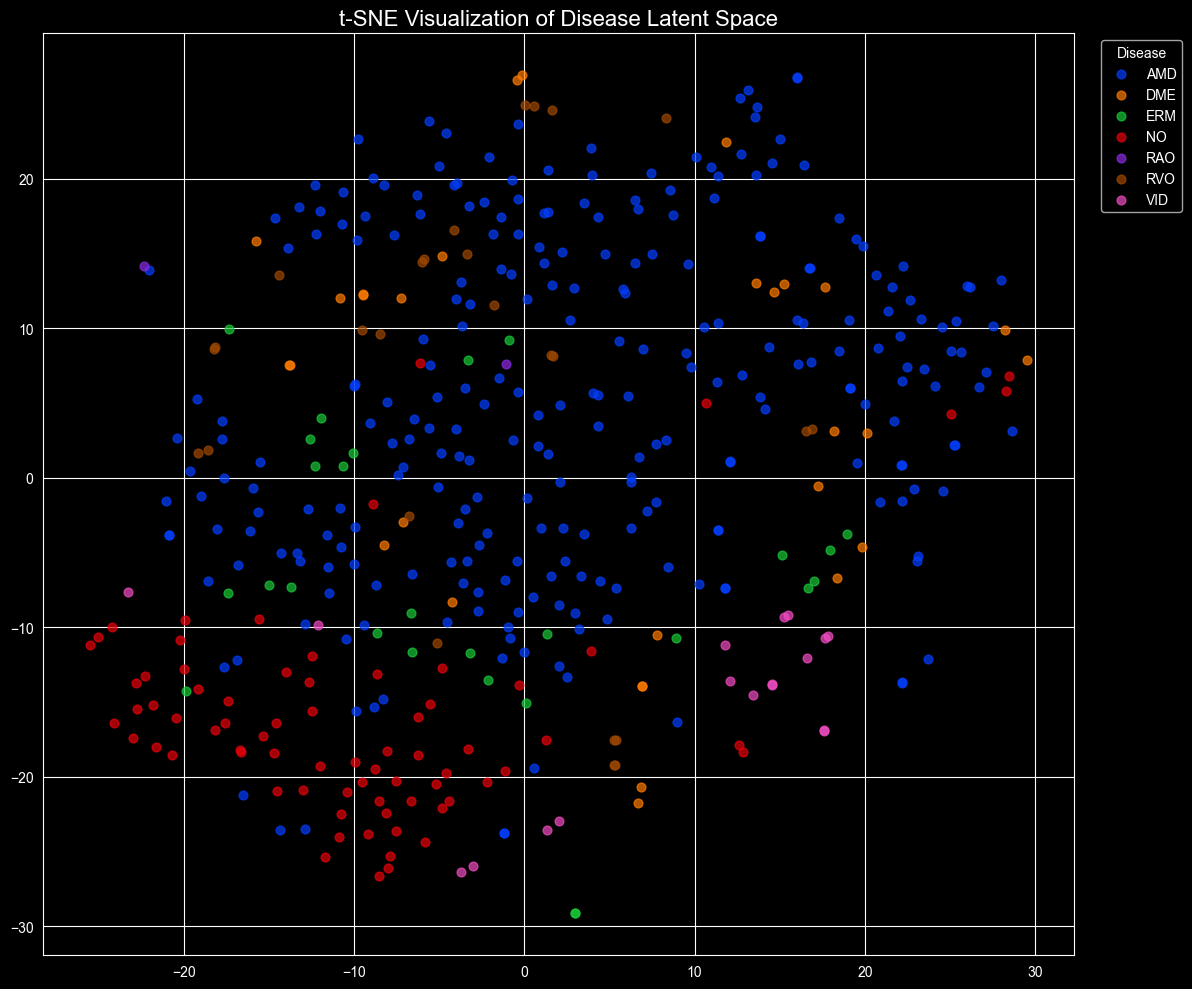

pytorch-grad-cam not installed. Skipping GradCAM visualization.


In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from torchvision import transforms

current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
output_dir = os.path.join(current_dir, "visualizations")
os.makedirs(output_dir, exist_ok=True)

CLASSIFIER_DIR = os.path.join(project_root, 'CLASSIFIER')
DATASET_PATH = r"C:\Datasets\OCTDL_Cleaned"
MODEL_PATH = os.path.join(project_root, "saved_models", "best_classifier.pth")
SSL_CHECKPOINT_PATH = os.path.join(project_root, "checkpoints_ssl", "checkpoint_latest.pth")

if CLASSIFIER_DIR not in sys.path:
    sys.path.insert(0, CLASSIFIER_DIR)

try:
    from dataset import get_data_splits, OCTDLMultiTaskDataset
    from model import OCTDLMultiTaskModel
    print(" Successfully imported project modules.")
except ImportError as e:
    print(f" Import Error: {e}")
    print(f"Searched in: {CLASSIFIER_DIR}")
    print("Please check if the folder name matches 'CLASSIFIER'.")

# --- CONFIGURATION ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f" Running on: {DEVICE}")

# --- LOAD DATA & MODEL ---
def load_resources():
    csv_path = os.path.join(DATASET_PATH, "OCTDL_clean_metadata.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Metadata not found at: {csv_path}")

    _, _, test_df, disease_map, condition_map = get_data_splits(csv_path)
    idx_to_disease = {v: k for k, v in disease_map.items()}

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_ds = OCTDLMultiTaskDataset(test_df, DATASET_PATH, val_transform, disease_map, condition_map)
    loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    init_checkpoint = SSL_CHECKPOINT_PATH
    if not os.path.exists(init_checkpoint):
        print(f" Warning: Can't find {SSL_CHECKPOINT_PATH}")
        init_checkpoint = MODEL_PATH

    print(f" Init model structure using: {init_checkpoint}")
    model = OCTDLMultiTaskModel(checkpoint_path=init_checkpoint, num_diseases=len(disease_map),
                                num_conditions=len(condition_map))

    if os.path.exists(MODEL_PATH):
        state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print(" Model weights loaded successfully.")
    else:
        raise FileNotFoundError(f"Model not found at: {MODEL_PATH}")

    model.to(DEVICE)
    model.eval()

    return model, loader, idx_to_disease, test_ds

model, test_loader, idx_to_disease, test_dataset = load_resources()

# --- T-SNE VISUALIZATION (Latent Space) ---
def plot_tsne():
    print(" Extracting features for t-SNE...")
    features = []
    labels = []

    with torch.no_grad():
        for images, d_labels, _ in tqdm(test_loader):
            images = images.to(DEVICE)
            feats = model.backbone(images)
            features.append(feats.cpu().numpy())
            labels.extend(d_labels.numpy())

    features = np.concatenate(features, axis=0)
    labels = np.array(labels)

    print("Computing t-SNE projection...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features)

    plt.figure(figsize=(12, 10))
    unique_labels = np.unique(labels)
    palette = sns.color_palette("bright", len(unique_labels))

    for i, lbl in enumerate(unique_labels):
        indices = labels == lbl
        plt.scatter(features_2d[indices, 0], features_2d[indices, 1],
                    label=idx_to_disease[lbl], color=palette[i], alpha=0.7, s=40)

    plt.title("t-SNE Visualization of Disease Latent Space", fontsize=16)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Disease")
    plt.tight_layout()

    save_path = os.path.join(output_dir, "tsne_plot.png")
    plt.savefig(save_path, dpi=300)
    print(f"t-SNE plot saved to: {save_path}")

    plt.show()

plot_tsne()

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

    def plot_gradcam(num_samples=3):
        print("Generating GradCAM heatmaps...")
        target_layers = [model.backbone.blocks[-1].norm1]
        cam = GradCAM(model=model, target_layers=target_layers)

        indices = np.random.choice(len(test_dataset), num_samples, replace=False)

        plt.figure(figsize=(10, 4 * num_samples))

        for i, idx in enumerate(indices):
            img_tensor, label_d, _ = test_dataset[idx]
            img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

            grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0, :]

            rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
            rgb_img = (rgb_img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
            rgb_img = np.clip(rgb_img, 0, 1)

            visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
            class_name = idx_to_disease[label_d.item()]

            plt.subplot(num_samples, 2, i*2 + 1)
            plt.imshow(rgb_img)
            plt.title(f"Original: {class_name}")
            plt.axis('off')

            plt.subplot(num_samples, 2, i*2 + 2)
            plt.imshow(visualization)
            plt.title(f"Model Attention")
            plt.axis('off')

        plt.tight_layout()

        save_path = os.path.join(output_dir, "gradcam_plot.png")
        plt.savefig(save_path, dpi=300)
        print(f"GradCAM plot saved to: {save_path}")

        plt.show()

    plot_gradcam(num_samples=4)

except ImportError:
    print("pytorch-grad-cam not installed. Skipping GradCAM visualization.")
except Exception as e:
    print(f"GradCAM error: {e}")
